In [ ]:
pip install spacy pandas matplotlib PyPDF2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 8.2 MB/s eta 0:00:00


✅ Текст успешно загружен из TXT.
Длина корпуса: 530683 символов

📊 Частота упоминаний персонажей Шекспира:
Персонаж  Частота
 Шекспир        2
  Дункан        1
  Гамлет        1


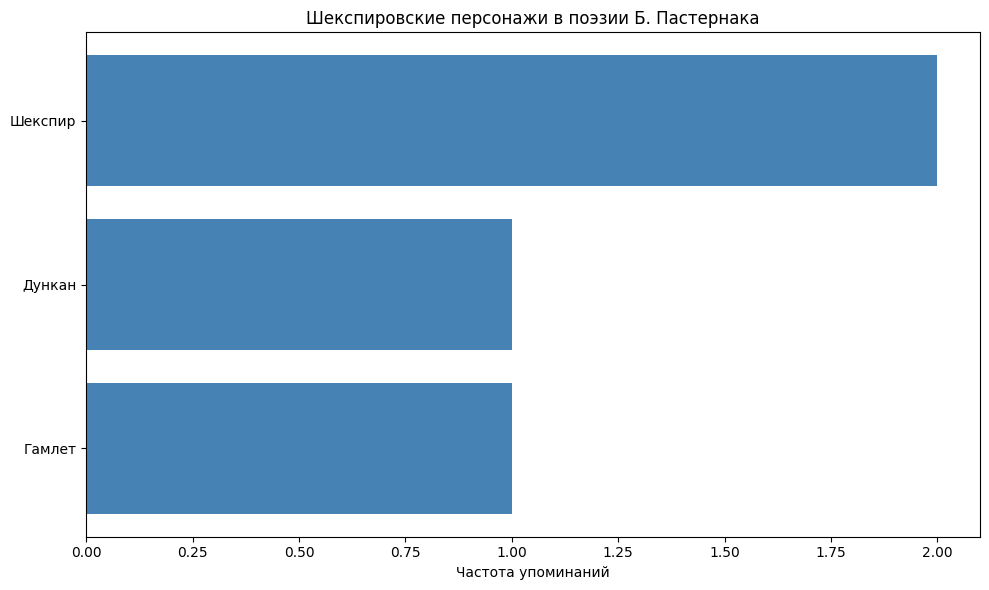


📄 Найдено 4 строк с упоминаниями:
 Номер строки                                     Строка Персонаж(и)
         3620                                    Шекспир     Шекспир
         4370             Дункан седых догадок - помощь!      Дункан
         5596 О! Весь Шекспир, быть может, только в том,     Шекспир
         5597       Что запросто болтает с тенью Гамлет.      Гамлет

✅ Результаты сохранены в 'shakespeare_exact_matches.csv'

✅ Частотный анализ сохранён в 'shakespeare_references_pasternak.csv'


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


txt_path = "/content/stihotvoreniya-i-poemy.txt"

try:
    with open(txt_path, "r", encoding="utf-8") as f:
        corpus = f.read()
    print("✅ Текст успешно загружен из TXT.")
except FileNotFoundError:
    print(f"❌ Файл не найден: {txt_path}")
    corpus = ""

print(f"Длина корпуса: {len(corpus)} символов")


shakespeare_names = {
    'Гамлет', 'Офелия', 'Дездемона', 'Макбет', 'Лаэрт', 'Горацио', 'Шекспир',
    'Ромео', 'Джульетта', 'Лоренцо', 'Меркуцио', 'Отелло', 'Кассио',
    'Дункан', 'Банко'
}


pattern = r'\b(' + '|'.join(re.escape(name) for name in shakespeare_names) + r')\b'
regex = re.compile(pattern, re.IGNORECASE)


lines = corpus.split('\n')
found_names = []
found_lines_data = []

for i, line in enumerate(lines, start=1):
    matches = regex.findall(line)
    if matches:

        unique_matches = list(set(m.title() for m in matches if m.title() in shakespeare_names))
        for char in unique_matches:
            found_names.append(char)
        found_lines_data.append({
            'Номер строки': i,
            'Строка': line.strip(),
            'Персонаж(и)': ', '.join(unique_matches)
        })


counter = Counter(found_names)
df_freq = pd.DataFrame(counter.items(), columns=['Персонаж', 'Частота'])
df_freq = df_freq.sort_values('Частота', ascending=False)

print("\n Частота упоминаний персонажей Шекспира:")
if not df_freq.empty:
    print(df_freq.to_string(index=False))
else:
    print("Ни одно точное совпадение не найдено.")


if not df_freq.empty:
    plt.figure(figsize=(10, 6))
    plt.barh(df_freq['Персонаж'], df_freq['Частота'], color='steelblue')
    plt.xlabel('Частота упоминаний')
    plt.title('Шекспировские персонажи в поэзии Б. Пастернака')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


if found_lines_data:
    df_lines = pd.DataFrame(found_lines_data)
    print(f"\n📄 Найдено {len(found_lines_data)} строк с упоминаниями:")
    print(df_lines.to_string(index=False, max_colwidth=80))


    df_lines.to_csv("/content/shakespeare_exact_matches.csv", index=False)
    print("\n Результаты сохранены в 'shakespeare_exact_matches.csv'")
else:
    print("\n Точные совпадения в строках не найдены.")


df_freq.to_csv("/content/shakespeare_references_pasternak.csv", index=False)
print("\n Частотный анализ сохранён в 'shakespeare_references_pasternak.csv'")

In [ ]:
pip install pymorphy3 pymorphy3-dicts-ru

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import PyPDF2
import pymorphy3


pdf_path = "/content/pasternak_stikhotvoreniya_i_poemy_1961__ocr.txt"

def extract_text_from_pdf(path):
    text = ""
    with open(path, "rb") as f:
        reader = PyPDF2.PdfReader(f)
        for page in reader.pages:
            extracted = page.extract_text()
            if extracted:
                text += extracted + "\n"
    return text

print("Извлечение текста из PDF...")
corpus = extract_text_from_pdf(pdf_path)
print(f"Длина корпуса: {len(corpus)} символов")


shakespeare_characters = {
    'Гамлет', 'Офелия', 'Дездемона', 'Макбет', 'Лаэрт', 'Горацио',
    'Ромео', 'Джульетта', 'Лоренцо', 'Меркуцио', 'Отелло', 'Кассио',
    'Дункан', 'Банко'
}


morph = pymorphy3.MorphAnalyzer(lang='ru')


def get_lemma(word):
    parses = morph.parse(word)
    if parses:
        return parses[0].normal_form
    return word


tokens = re.findall(r'\b\w+\b', corpus.lower())


found_lemmas = []
character_hits = []

for token in tokens:
    lemma = get_lemma(token)

    if lemma.title() in shakespeare_characters:
        found_lemmas.append(lemma.title())
        character_hits.append((token, lemma.title()))


counter = Counter(found_lemmas)
df = pd.DataFrame(counter.items(), columns=['Персонаж', 'Частота'])
df = df.sort_values('Частота', ascending=False)

print("\nЧастота упоминаний персонажей Шекспира (после лемматизации):")
print(df)


if not df.empty:
    plt.figure(figsize=(10, 6))
    plt.barh(df['Персонаж'], df['Частота'], color='steelblue')
    plt.xlabel('Частота упоминаний')
    plt.title('Шекспировские персонажи в поэзии Б. Пастернака')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Ни один персонаж не найден — даже после лемматизации.")


if character_hits:
    print("\nПримеры найденных форм:")
    for raw, norm in character_hits[:10]:
        print(f"  '{raw}' → '{norm}'")

Извлечение текста из PDF...
Длина корпуса: 193384 символов

Частота упоминаний персонажей Шекспира (после лемматизации):
Empty DataFrame
Columns: [Персонаж, Частота]
Index: []
Ни один персонаж не найден — даже после лемматизации.


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import PyPDF2


pdf_path = "/content/pasternak_stikhotvoreniya_i_poemy_1961__ocr.pdf"

def extract_text_from_pdf(path):
    text = ""
    with open(path, "rb") as f:
        reader = PyPDF2.PdfReader(f)
        for page in reader.pages:
            extracted = page.extract_text()
            if extracted:
                text += extracted + "\n"
    return text

print("Извлечение текста из PDF...")
corpus = extract_text_from_pdf(pdf_path)
print(f"Длина корпуса: {len(corpus)} символов")



character_forms = {
    'Гамлет': [
        'гамлет', 'гамлета', 'гамлету', 'гамлетом', 'гамлете',
        'гамлетов', 'гамлетова', 'гамлетовы', 'гамлетовых', 'гамлетовым'
    ],
    'Офелия': [
        'офелия', 'офелии', 'офелию', 'офелией', 'офелие',
        'офелиины', 'офелиин', 'офелииных'
    ],
    'Дездемона': [
        'дездемона', 'дездемону', 'дездемоной', 'дездемоны', 'дездемоне'
    ],
    'Макбет': [
        'макбет', 'макбета', 'макбету', 'макбетом', 'макбете',
        'макбетов', 'макбетова', 'макбетовы', 'макбетовых', 'макбетовым',
        'макбетовы ведьмы', 'макбетовых ведьм'
    ],
    'Лаэрт': ['лаэрт', 'лаэрта', 'лаэрту', 'лаэртом', 'лаэрте'],
    'Горацио': ['горацио'],  # имя несклоняемое
    'Ромео': ['ромео'],
    'Джульетта': ['джульетта', 'джульетту', 'джульеттой', 'джульетты', 'джульетте'],
    'Лоренцо': ['лоренцо'],
    'Меркуцио': ['меркуцио'],
    'Отелло': ['отелло', 'отелло', 'отелло'],
    'Кассио': ['кассio', 'кассио'],
    'Дункан': ['дункан', 'дункана', 'дункану', 'дунканом', 'дункане'],
    'Банко': ['банко']
}

all_forms = {}
for canon, forms in character_forms.items():
    for f in forms:
        all_forms[f.lower()] = canon

text_lower = corpus.lower()

found = []
hits = []


for form, canon in all_forms.items():

    pattern = r'\b' + re.escape(form) + r'\b'
    matches = re.findall(pattern, text_lower)
    if matches:
        count = len(matches)
        found.extend([canon] * count)
        hits.append((form, canon, count))


counter = Counter(found)
df = pd.DataFrame(counter.items(), columns=['Персонаж', 'Частота'])
df = df.sort_values('Частота', ascending=False)

print("\nЧастота упоминаний персонажей Шекспира (расширенный поиск):")
if df.empty:
    print("Всё ещё не найдено. Возможно, проблемы с OCR или формами.")
else:
    print(df)

if not df.empty:
    plt.figure(figsize=(10, 6))
    plt.barh(df['Персонаж'], df['Частота'], color='steelblue')
    plt.xlabel('Частота упоминаний')
    plt.title('Шекспировские персонажи в поэзии Б. Пастернака')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Ни один персонаж не найден.")


if hits:
    print("\nНайденные формы:")
    for form, canon, cnt in hits[:15]:
        print(f"  '{form}' → '{canon}' (встречено {cnt} раз)")
else:

    print("\nПопытка найти фрагменты имён...")
    rough_hits = []
    for canon in character_forms.keys():
        pattern = re.escape(canon.lower())
        matches = re.findall(pattern, text_lower)
        if matches:
            rough_hits.append((canon, len(matches)))
    if rough_hits:
        print("Найдено по фрагментам:")
        for canon, cnt in rough_hits:
            print(f"  {canon}: {cnt} раз")
    else:
        print("Даже фрагменты не найдены. Проверьте качество PDF и кодировку.")

Извлечение текста из PDF...
Длина корпуса: 193384 символов

Частота упоминаний персонажей Шекспира (расширенный поиск):
Всё ещё не найдено. Возможно, проблемы с OCR или формами.
Ни один персонаж не найден.

Попытка найти фрагменты имён...
Найдено по фрагментам:
  Банко: 1 раз


In [ ]:
pip install fuzzywuzzy python-Levenshtein pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 64.3 MB/s eta 0:00:00


✅ Текст успешно загружен из TXT.
Длина корпуса: 210703 символов

📊 Частота упоминаний персонажей Шекспира (с нечётким поиском):
 Персонаж  Частота
   Гамлет        3
    Ромео        3
   Кассио        1
Дездемона        1


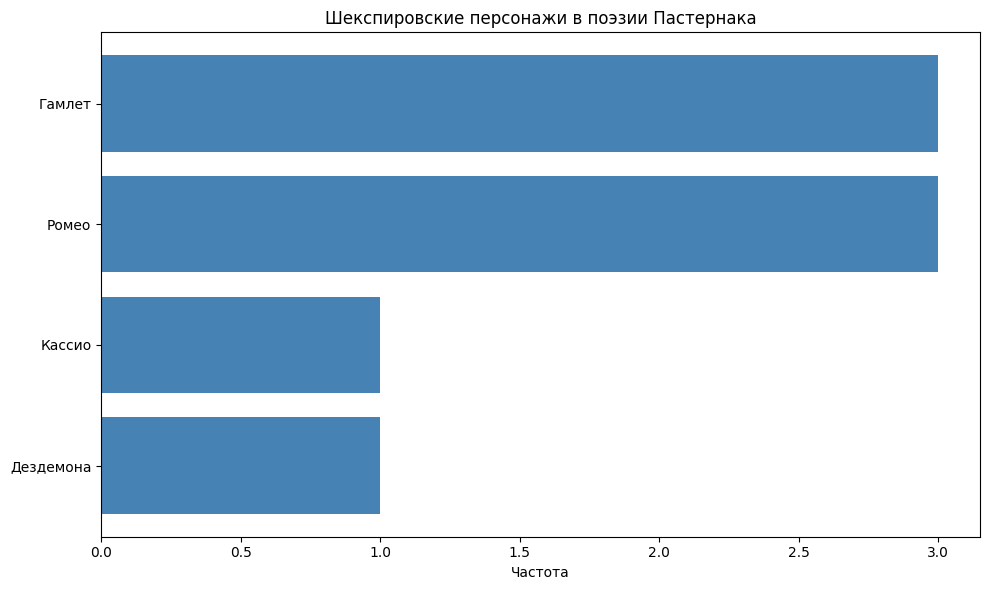


🔍 Найдено 8 нечётких совпадений (порог ≥80):
  'гаме' → 'Гамлет' (score=80)
  'касс,' → 'Кассио' (score=80)
  'ДЕМОНА' → 'Дездемона' (score=80)
  'Млет.' → 'Гамлет' (score=80)
  'Кроме' → 'Ромео' (score=80)
  'кроме' → 'Ромео' (score=80)
  'гаме,' → 'Гамлет' (score=80)
  'Ромен' → 'Ромео' (score=80)


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from fuzzywuzzy import fuzz, process


txt_path = "/content/pasternak_stikhotvoreniya_i_poemy_1961__ocr.txt"

try:
    with open(txt_path, "r", encoding="utf-8") as f:
        corpus = f.read()
    print("✅ Текст успешно загружен из TXT.")
except FileNotFoundError:
    print(f"❌ Файл не найден: {txt_path}")
    corpus = ""

print(f"Длина корпуса: {len(corpus)} символов")


shakespeare_characters = [
    'Гамлет', 'Офелия', 'Дездемона', 'Макбет', 'Лаэрт', 'Горацио',
    'Ромео', 'Джульетта', 'Лоренцо', 'Меркуцио', 'Отелло', 'Кассио',
    'Дункан', 'Банко'
]


tokens = re.findall(r'\S+', corpus)


found_exact = []
found_fuzzy = []


SIMILARITY_THRESHOLD = 80

for token in tokens:

    clean_token = re.sub(r'[^\w]', '', token)
    if not clean_token:
        continue


    if clean_token.title() in shakespeare_characters:
        found_exact.append(clean_token.title())
        continue


    match, score = process.extractOne(clean_token, shakespeare_characters, scorer=fuzz.token_sort_ratio)
    if score >= SIMILARITY_THRESHOLD:
        found_fuzzy.append((token, match, score))
        found_exact.append(match)


all_matches = found_exact


counter = Counter(all_matches)
df = pd.DataFrame(counter.items(), columns=['Персонаж', 'Частота'])
df = df.sort_values('Частота', ascending=False)

print("\n Частота упоминаний персонажей Шекспира (с нечётким поиском):")
if df.empty:
    print("Ни один персонаж не найден.")
else:
    print(df.to_string(index=False))


if not df.empty:
    plt.figure(figsize=(10, 6))
    plt.barh(df['Персонаж'], df['Частота'], color='steelblue')
    plt.xlabel('Частота')
    plt.title('Шекспировские персонажи в поэзии Пастернака')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


if found_fuzzy:
    print(f"\n Найдено {len(found_fuzzy)} нечётких совпадений (порог ≥{SIMILARITY_THRESHOLD}):")

    for raw, canon, score in found_fuzzy[:10]:
        print(f"  '{raw}' → '{canon}' (score={score})")
else:
    print("\n Нечёткие совпадения не найдены.")

✅ Текст успешно загружен из TXT.
Длина корпуса: 210703 символов

📊 Частота упоминаний персонажей Шекспира:
 Персонаж  Частота
   Гамлет        3
    Ромео        3
   Кассио        1
Дездемона        1


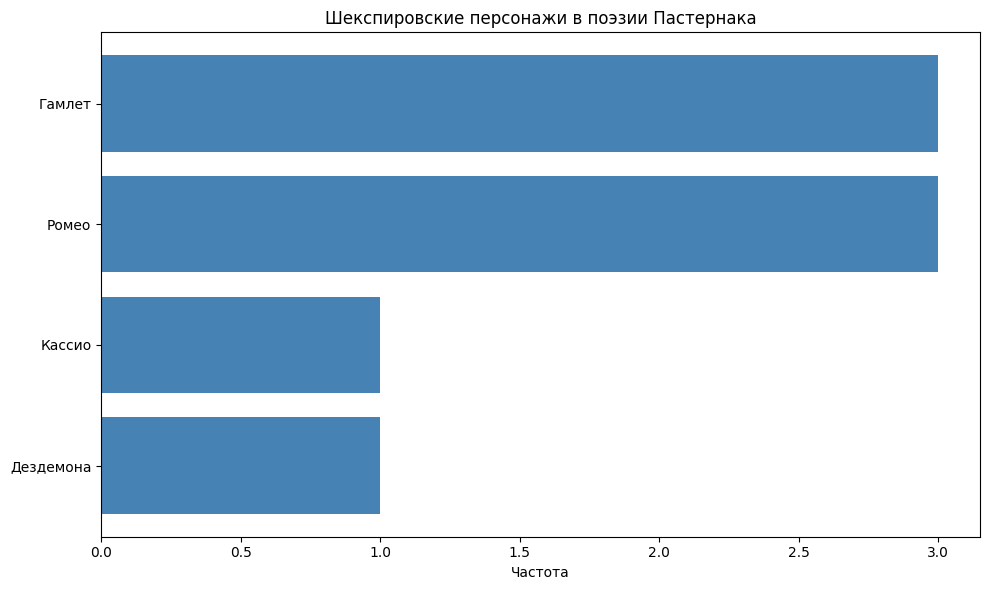


🔍 Точные совпадения в строках не найдены.

🔍 Найдено 8 нечётких совпадений (порог ≥80):
  'гаме' → 'Гамлет' (score=80)
  'касс,' → 'Кассио' (score=80)
  'ДЕМОНА' → 'Дездемона' (score=80)
  'Млет.' → 'Гамлет' (score=80)
  'Кроме' → 'Ромео' (score=80)
  'кроме' → 'Ромео' (score=80)
  'гаме,' → 'Гамлет' (score=80)
  'Ромен' → 'Ромео' (score=80)


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from fuzzywuzzy import fuzz, process


txt_path = "/content/pasternak_stikhotvoreniya_i_poemy_1961__ocr.txt"

try:
    with open(txt_path, "r", encoding="utf-8") as f:
        corpus = f.read()
    print(" Текст успешно загружен из TXT.")
except FileNotFoundError:
    print(f" Файл не найден: {txt_path}")
    corpus = ""

print(f"Длина корпуса: {len(corpus)} символов")


shakespeare_characters = [
    'Гамлет', 'Офелия', 'Дездемона', 'Макбет', 'Лаэрт', 'Горацио',
    'Ромео', 'Джульетта', 'Лоренцо', 'Меркуцио', 'Отелло', 'Кассио',
    'Дункан', 'Банко'
]

character_set = set(shakespeare_characters)


lines = corpus.split('\n')


found_exact = []
exact_lines_data = []

for i, line in enumerate(lines, start=1):

    words = re.findall(r'\w+', line.lower())
    detected_chars = set()
    for word in words:
        candidate = word.title()
        if candidate in character_set:
            detected_chars.add(candidate)

    for char in detected_chars:
        found_exact.append(char)
        exact_lines_data.append({
            'Номер строки': i,
            'Строка': line.strip(),
            'Персонаж': char
        })


tokens = re.findall(r'\S+', corpus)
found_fuzzy = []
SIMILARITY_THRESHOLD = 80
for token in tokens:
    clean_token = re.sub(r'[^\w]', '', token)
    if not clean_token or clean_token.title() in character_set:
        continue
    match, score = process.extractOne(clean_token, shakespeare_characters, scorer=fuzz.token_sort_ratio)
    if score >= SIMILARITY_THRESHOLD:
        found_fuzzy.append((token, match, score))
        found_exact.append(match)


counter = Counter(found_exact)
df_freq = pd.DataFrame(counter.items(), columns=['Персонаж', 'Частота'])
df_freq = df_freq.sort_values('Частота', ascending=False)

print("\n📊 Частота упоминаний персонажей Шекспира:")
if not df_freq.empty:
    print(df_freq.to_string(index=False))
else:
    print("Ни один персонаж не найден.")


if not df_freq.empty:
    plt.figure(figsize=(10, 6))
    plt.barh(df_freq['Персонаж'], df_freq['Частота'], color='steelblue')
    plt.xlabel('Частота')
    plt.title('Шекспировские персонажи в поэзии Пастернака')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


if exact_lines_data:
    df_lines = pd.DataFrame(exact_lines_data)
    print("\n Строки с точными упоминаниями персонажей:")
    print(df_lines.to_string(index=False))


    df_lines.to_csv("/content/shakespeare_lines.csv", index=False)
    print("\n Строки сохранены в 'shakespeare_lines.csv'")
else:
    print("\n🔍 Точные совпадения в строках не найдены.")


if found_fuzzy:
    print(f"\n Найдено {len(found_fuzzy)} нечётких совпадений (порог ≥{SIMILARITY_THRESHOLD}):")
    for raw, canon, score in found_fuzzy[:10]:
        print(f"  '{raw}' → '{canon}' (score={score})")

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


txt_path = "/content/pasternak_stikhotvoreniya_i_poemy_1961__ocr.txt"

try:
    with open(txt_path, "r", encoding="utf-8") as f:
        corpus = f.read()
    print(" Текст успешно загружен из TXT.")
except FileNotFoundError:
    print(f" Файл не найден: {txt_path}")
    corpus = ""

print(f"Длина корпуса: {len(corpus)} символов")


shakespeare_characters = [
    'Гамлет', 'Офелия', 'Дездемона', 'Макбет', 'Лаэрт', 'Горацио',
    'Ромео', 'Джульетта', 'Лоренцо', 'Меркуцио', 'Отелло', 'Кассио',
    'Дункан', 'Банко'
]


pattern = r'\b(' + '|'.join(re.escape(name) for name in shakespeare_characters) + r')\b'
regex = re.compile(pattern, re.IGNORECASE)

# === 4. Анализ по строкам ===
lines = corpus.split('\n')
found_lines = []
all_matches = []

for i, line in enumerate(lines, start=1):

    matches = regex.findall(line)
    if matches:

        normalized_matches = []
        line_lower = line.lower()
        for name in shakespeare_characters:
            if name.lower() in line_lower:
                normalized_matches.append(name)

        unique_matches = list(set(normalized_matches))
        for char in unique_matches:
            all_matches.append(char)

        found_lines.append({
            'Номер строки': i,
            'Строка': line.strip(),
            'Персонаж(и)': ', '.join(unique_matches)
        })


counter = Counter(all_matches)
df_freq = pd.DataFrame(counter.items(), columns=['Персонаж', 'Частота'])
df_freq = df_freq.sort_values('Частота', ascending=False)

print("\n Частота упоминаний персонажей Шекспира (только точные совпадения):")
if not df_freq.empty:
    print(df_freq.to_string(index=False))
else:
    print("Ни одно точное совпадение не найдено.")


if not df_freq.empty:
    plt.figure(figsize=(10, 6))
    plt.barh(df_freq['Персонаж'], df_freq['Частота'], color='steelblue')
    plt.xlabel('Частота')
    plt.title('Шекспировские персонажи в поэзии Пастернака')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


if found_lines:
    print(f"\n📄 Найдено {len(found_lines)} строк с точными упоминаниями:")
    df_lines = pd.DataFrame(found_lines)

    print(df_lines.head(20).to_string(index=False))


    df_lines.to_csv("/content/shakespeare_exact_matches.csv", index=False)
    print("\n Все совпадения сохранены в 'shakespeare_exact_matches.csv'")
else:
    print("\n Точные совпадения в строках не найдены.")

✅ Текст успешно загружен из TXT.
Длина корпуса: 210703 символов

📊 Частота упоминаний персонажей Шекспира (только точные совпадения):
Ни одно точное совпадение не найдено.

🔍 Точные совпадения в строках не найдены.


✅ Текст загружен.

📊 Найденные персонажи:
 Персонаж  Частота
Дездемона        2
   Гамлет        2
   Офелия        2
   Макбет        1
   Дункан        1


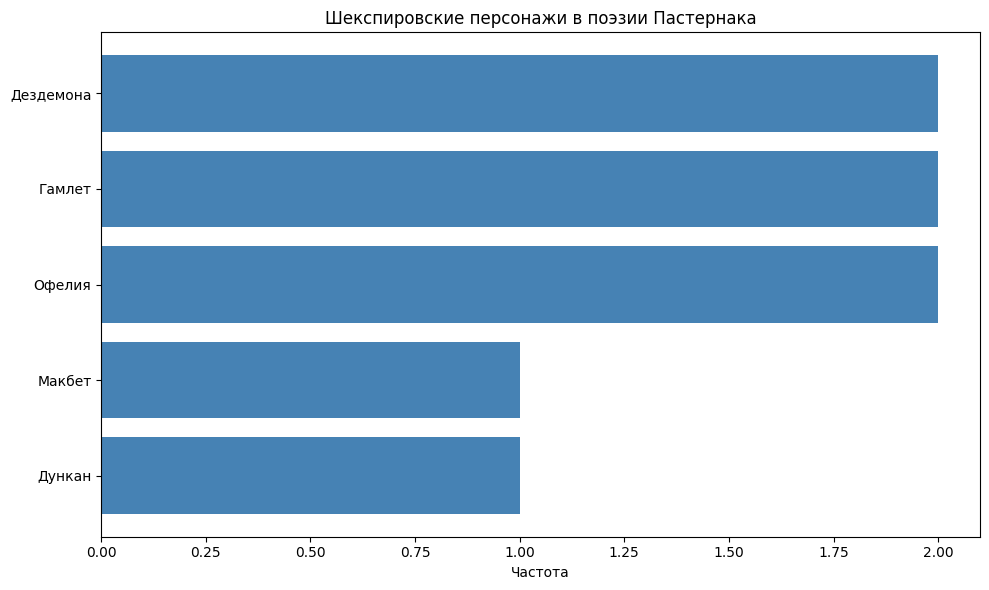


📄 Найдено 8 строк с упоминаниями:
 Номер строки                               Строка Персонаж(и)
          492  Но медных макбетовых ведьм в дыму -      Макбет
         2315    Когда случилось петь Дездемоне, -   Дездемона
         2320       Когда случилось петь Дездемоне   Дездемона
         2325       Когда случилось петь Офелии, -      Офелия
         2330       Когда случилось петь Офелии, -      Офелия
         3100          Фауста, что ли, Гамлета ли,      Гамлет
         4370       Дункан седых догадок - помощь!      Дункан
         5597 Что запросто болтает с тенью Гамлет.      Гамлет

✅ Сохранено в 'shakespeare_exact_and_derived.csv'


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


txt_path = "/content/stihotvoreniya-i-poemy.txt"
try:
    with open(txt_path, "r", encoding="utf-8") as f:
        corpus = f.read()
    print(" Текст загружен.")
except FileNotFoundError:
    print(f" Файл не найден: {txt_path}")
    corpus = ""


character_variants = {
    'Гамлет': [
        'гамлет', 'гамлета', 'гамлету', 'гамлетом', 'гамлете',
        'гамлетов', 'гамлетова', 'гамлетовы', 'гамлетовых', 'гамлетовым'
    ],
    'Офелия': [
        'офелия', 'офелии', 'офелию', 'офелией', 'офелие',
        'офелиины', 'офелиин', 'офелииных'
    ],
    'Дездемона': [
        'дездемона', 'дездемону', 'дездемоной', 'дездемоны', 'дездемоне'
    ],
    'Макбет': [
        'макбет', 'макбета', 'макбету', 'макбетом', 'макбете',
        'макбетов', 'макбетова', 'макбетовы', 'макбетовых', 'макбетовым',
        'макбетовых ведьм', 'макбетовы ведьмы'
    ],
    'Лаэрт': ['лаэрт', 'лаэрта', 'лаэрту', 'лаэртом', 'лаэрте'],
    'Горацио': ['горацио'],
    'Ромео': ['ромео'],
    'Джульетта': ['джульетта', 'джульетту', 'джульеттой', 'джульетты', 'джульетте'],
    'Лоренцо': ['лоренцо'],
    'Меркуцио': ['меркуцио'],
    'Отелло': ['отелло'],
    'Кассио': ['кассio', 'кассио'],
    'Дункан': ['дункан', 'дункана', 'дункану', 'дунканом', 'дункане'],
    'Банко': ['банко']
}


form_to_canonical = {}
for canon, forms in character_variants.items():
    for f in forms:
        form_to_canonical[f.lower()] = canon


all_forms = sorted(form_to_canonical.keys(), key=len, reverse=True)


lines = corpus.split('\n')
found_lines = []
all_matches = []


escaped_forms = [re.escape(f) for f in all_forms]
pattern = r'\b(?:' + '|'.join(escaped_forms) + r')\b'
regex = re.compile(pattern, re.IGNORECASE)


for i, line in enumerate(lines, start=1):
    line_lower = line.lower()
    matches_in_line = set()


    for match in regex.finditer(line_lower):
        matched_text = match.group()
        if matched_text in form_to_canonical:
            canon = form_to_canonical[matched_text]
            matches_in_line.add(canon)

    if matches_in_line:
        for char in matches_in_line:
            all_matches.append(char)
        found_lines.append({
            'Номер строки': i,
            'Строка': line.strip(),
            'Персонаж(и)': ', '.join(matches_in_line)
        })


counter = Counter(all_matches)
df_freq = pd.DataFrame(counter.items(), columns=['Персонаж', 'Частота'])
df_freq = df_freq.sort_values('Частота', ascending=False)

print("\n Найденные персонажи:")
if not df_freq.empty:
    print(df_freq.to_string(index=False))
else:
    print("Ничего не найдено.")


if not df_freq.empty:
    plt.figure(figsize=(10, 6))
    plt.barh(df_freq['Персонаж'], df_freq['Частота'], color='steelblue')
    plt.xlabel('Частота')
    plt.title('Шекспировские персонажи в поэзии Пастернака')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


if found_lines:
    print(f"\n📄 Найдено {len(found_lines)} строк с упоминаниями:")
    df_lines = pd.DataFrame(found_lines)
    print(df_lines.to_string(index=False, max_colwidth=80))
    df_lines.to_csv("/content/shakespeare_exact_and_derived.csv", index=False)
    print("\n Сохранено в 'shakespeare_exact_and_derived.csv'")
else:
    print("\n Ничего не найдено в строках.")